In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')


In [2]:
df = pd.read_csv('heart.csv')
target = 'HeartDisease'

df_eda = df.copy()
for c in ['RestingBP', 'Cholesterol']:
    if c in df_eda.columns:
        df_eda.loc[df_eda[c] == 0, c] = np.nan

df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
df.shape
df.info()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


np.int64(0)

df.info() shows that the dataset has 918 rows and 12 columns, and there are no missing values (NaN) for the "Non-Null Count."
dtypes: 5 categorical (str), 1 float (Oldpeak), the rest are integer.
np.int64(0) is simply the number 0 in NumPy format. This is most likely the result of the df.duplicated().sum() cell and means there are no duplicate rows.

`Age`: age (years).
`Sex`: gender (`M`/`F`).
`ChestPainType`: chest pain type (category).
`RestingBP`: resting blood pressure (mmHg). Zeros may indicate "probably not measured".
`Cholesterol`: cholesterol (mmHg/dl). Zeros may indicate "probably not measured".
`FastingBS`: fasting blood sugar greater than 120 mg/dl: `1` - yes, `0` - no.
`RestingECG`: resting ECG (category).
`MaxHR`: maximum heart rate achieved.
`ExerciseAngina`: angina during exercise (`Y`/`N`).
`Oldpeak`: ST depression (number; negative values may be present).
`ST_Slope`: ST segment slope during exercise (category).
`HeartDisease` (target): `1` — heart disease present, `0` — no heart disease.

In [4]:
df.isna().sum().sort_values(ascending=False)
# «Чистые» для EDA пропуски (в т.ч. нули как NaN)
df_eda.isna().sum().sort_values(ascending=False)

Cholesterol       172
RestingBP           1
Sex                 0
Age                 0
ChestPainType       0
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak             0
ST_Slope            0
HeartDisease        0
dtype: int64

After data preparation, missing values were identified for only two variables: cholesterol (172 missing values) and blood pressure (1 missing value). There were no missing values for any other variables.

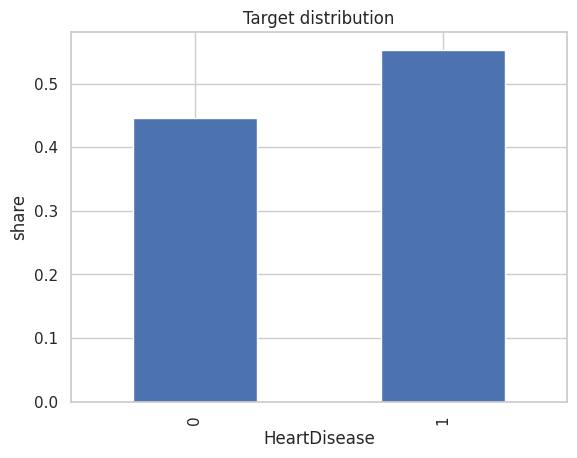

np.float64(0.5533769063180828)

In [5]:
target
df[target].value_counts(dropna=False)
ax = df[target].value_counts(normalize=True).sort_index().plot(kind='bar')
ax.set_title('Target distribution')
ax.set_xlabel(target)
ax.set_ylabel('share')
plt.show()
share_pos = df[target].mean()
share_pos

The target variable is relatively balanced: class 1 accounts for 55.3%, class 0 for 44.7%. There is a slight predominance of the positive class, but there is no significant imbalance.

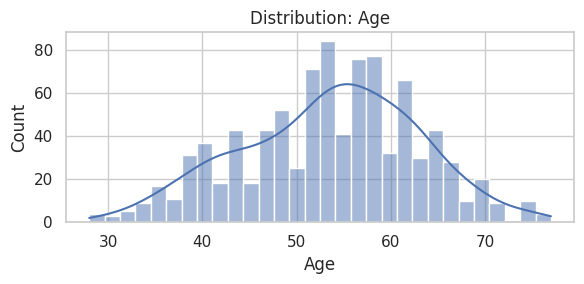

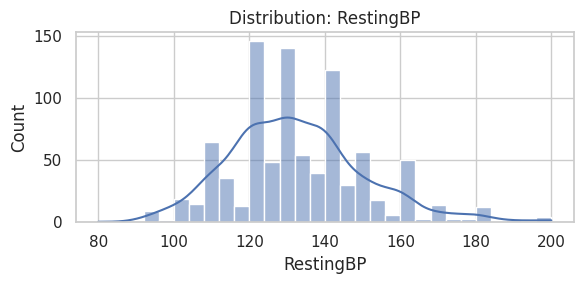

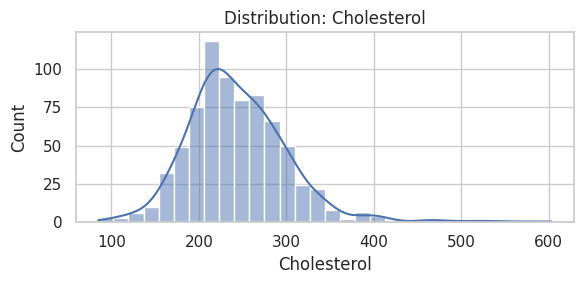

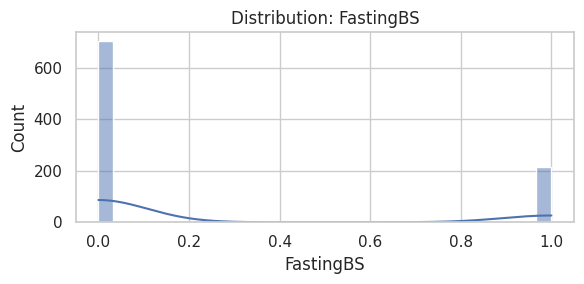

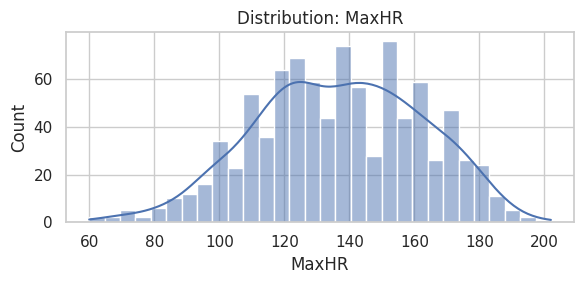

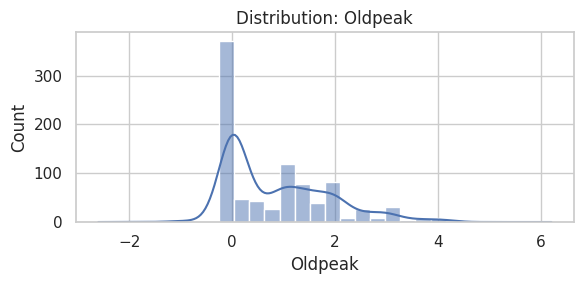

In [6]:
num_cols = [c for c in df_eda.select_dtypes(include=[np.number]).columns if c != target]
cat_cols = [c for c in df_eda.columns if c not in num_cols + [target]]
num_cols, cat_cols
for c in num_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(df_eda[c], kde=True, bins=30)
    plt.title(f'Distribution: {c}')
    plt.tight_layout()
    plt.show()

An analysis of the distributions of the numerical features revealed that the Age and MaxHR variables have relatively smooth, nearly symmetrical distributions. The RestingBP feature also has a unimodal distribution but exhibits moderate right-sided asymmetry. The Cholesterol and Oldpeak variables are characterized by pronounced right-sided asymmetry and the presence of rare high values, which may indicate outliers. The FastingBS feature is binary and significantly biased toward the value 0, so it is appropriate to analyze it as a categorical feature.

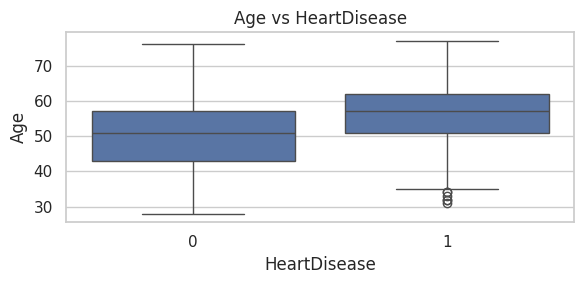

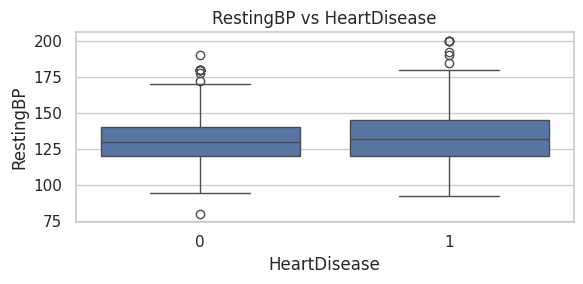

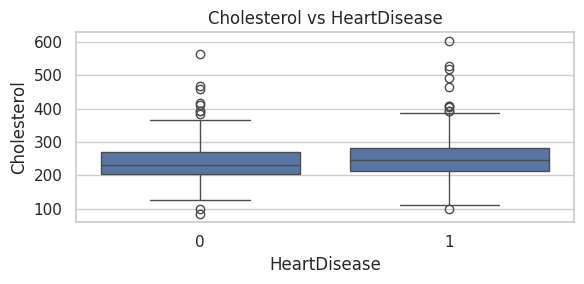

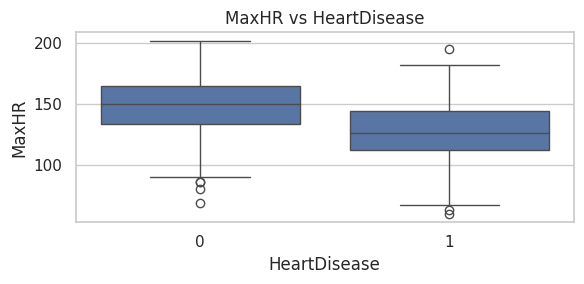

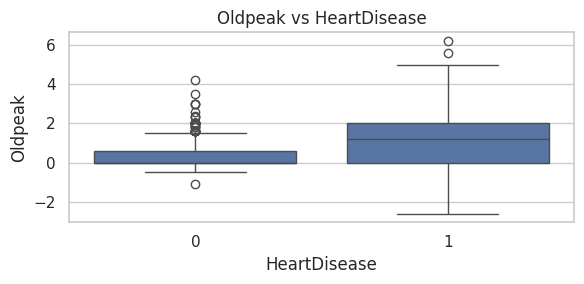

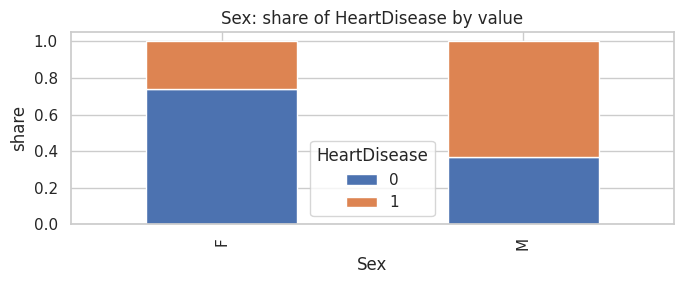

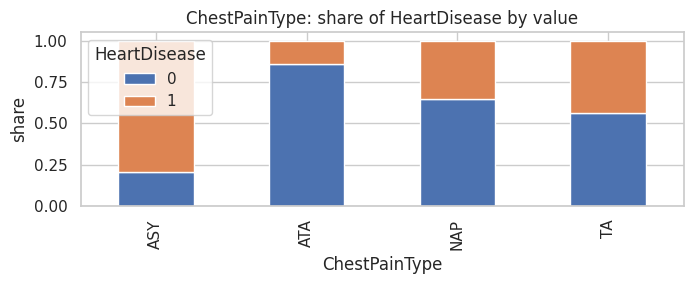

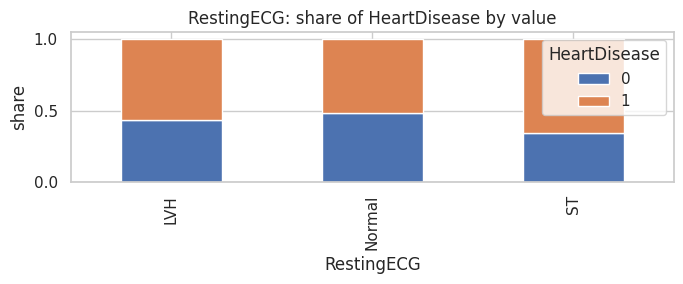

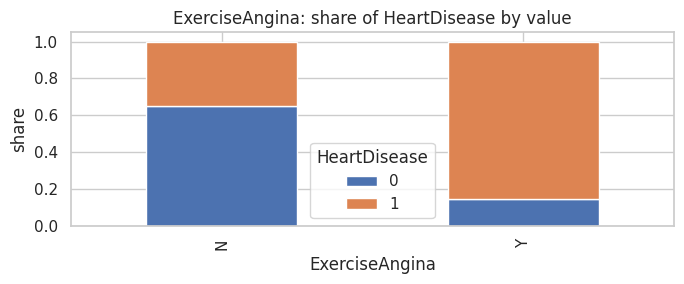

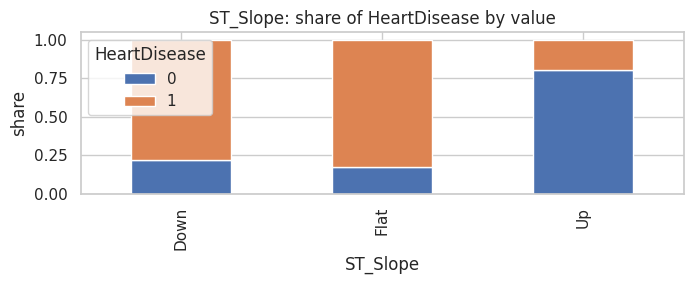

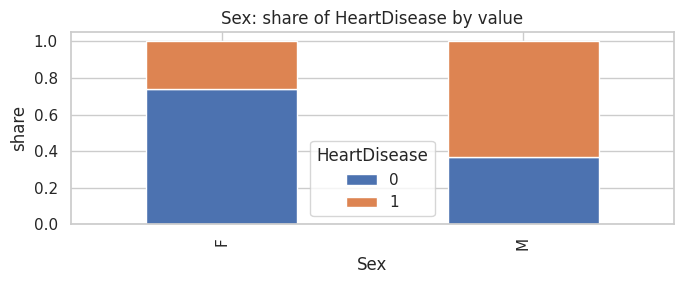

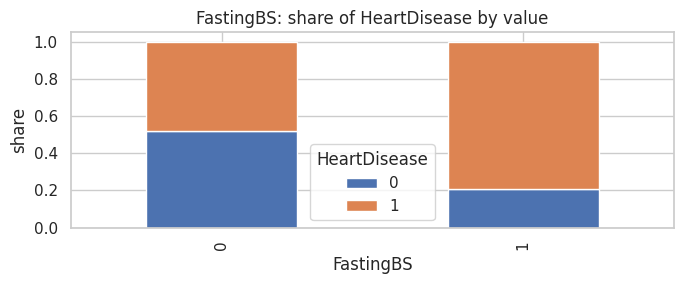

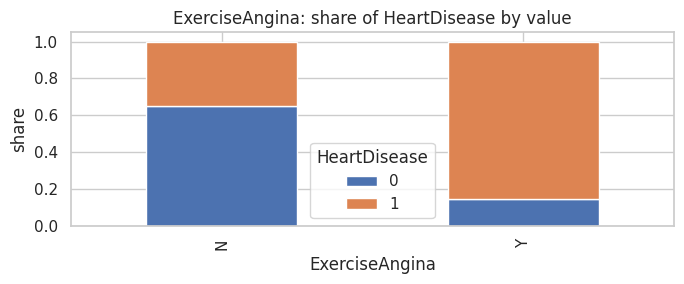

In [7]:
binary_like = []
for c in df_eda.columns:
    if c == target:
        continue
    u = df_eda[c].dropna().unique()
    if len(u) <= 2:
        binary_like.append(c)
binary_like
# Числовые vs target
for c in [x for x in num_cols if x not in binary_like]:
    plt.figure(figsize=(6, 3))
    sns.boxplot(data=df_eda, x=target, y=c)
    plt.title(f'{c} vs {target}')
    plt.tight_layout()
    plt.show()
    # Категориальные (включая бинарные) vs target
for c in cat_cols + binary_like:
    if c == target:
        continue
    ct = pd.crosstab(df[c], df[target], normalize='index')
    ax = ct.plot(kind='bar', stacked=True, figsize=(7, 3))
    ax.set_title(f'{c}: share of {target} by value')
    ax.set_ylabel('share')
    plt.tight_layout()
    plt.show()

An analysis of the dependence of features on the target variable revealed that the presence of heart disease is more common in older patients, as well as in patients with higher Oldpeak values and lower MaxHR values. The RestingBP and Cholesterol features demonstrate a weaker relationship with the target variable due to significant overlap in distributions between classes. Among the categorical features, the most significant associations with HeartDisease are observed for ChestPainType, ExerciseAngina, ST_Slope, as well as the features Sex and FastingBS. Specifically, the presence of angina during exercise, ST_Slope = Flat/Down values, ASY chest pain type, and male gender are associated with a higher proportion of patients with heart disease.

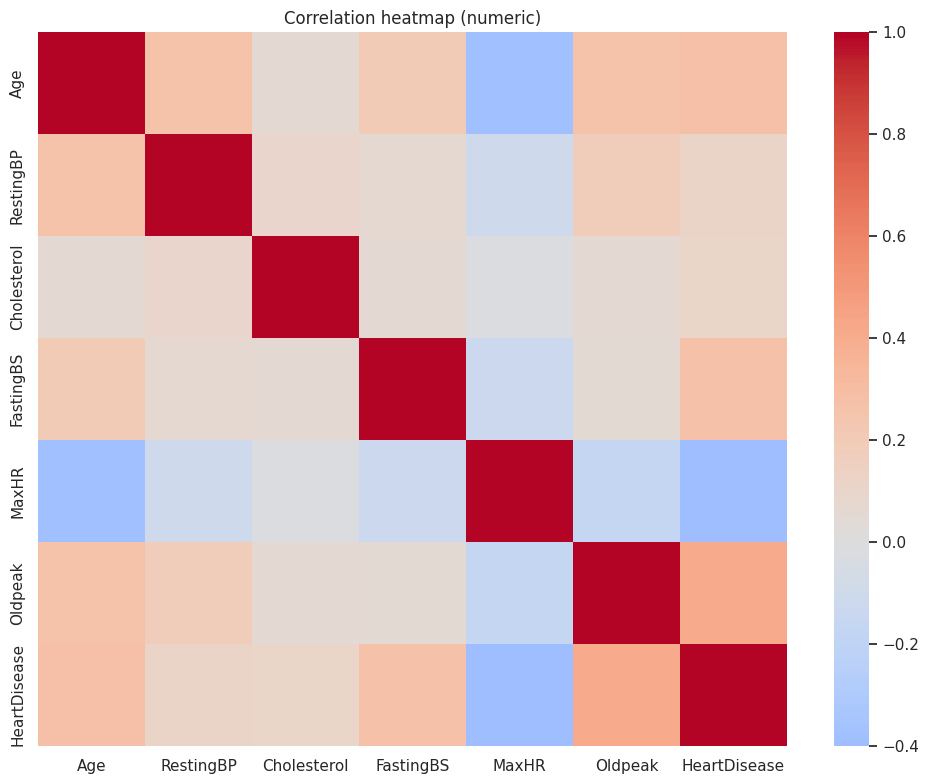

In [8]:
corr = df_eda[[*num_cols, target]].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation heatmap (numeric)')
plt.tight_layout()
plt.show()

Correlation analysis of the numerical features revealed that the Oldpeak and MaxHR features had the strongest association with the target variable HeartDisease. Oldpeak correlates positively with the presence of the disease, while MaxHR demonstrates a negative association. The Age and FastingBS features have a weak positive correlation with the target variable. For RestingBP and Cholesterol, the linear association with HeartDisease is weak.
It was also found that there are no strong correlations between the numerical features, indicating no significant multicollinearity in the data.

In [9]:
def iqr_outlier_share(s: pd.Series) -> float:
    s = s.dropna()
    if s.empty:
        return 0.0
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return 0.0
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return float(((s < lo) | (s > hi)).mean())

outlier_report = (
    pd.Series({c: iqr_outlier_share(df_eda[c]) for c in num_cols})
    .sort_values(ascending=False)
)
outlier_report

Cholesterol    0.030831
RestingBP      0.029444
Oldpeak        0.017429
MaxHR          0.002179
Age            0.000000
FastingBS      0.000000
dtype: float64